Found local copy...
Loading...
Done!


Extracting ZINC features...
Extracting CYP2D6 features...

ZINC charset (35): ['\n', '#', '(', ')', '+', '-', '/', '1', '2', '3', '4', '5', '6', '7', '8', '=', '@', 'B', 'C', 'F', 'H', 'I', 'N', 'O', 'P', 'S', '[', '\\', ']', 'c', 'l', 'n', 'o', 'r', 's']
CYP2D6 charset (52): ['#', '%', '(', ')', '+', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '=', '@', 'A', 'B', 'C', 'F', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'W', 'Z', '[', '\\', ']', 'a', 'b', 'c', 'e', 'g', 'i', 'l', 'n', 'o', 'r', 's', 't', 'u']
In CYP not in ZINC: {'t', 'b', 'A', 'a', 'W', '0', '.', 'g', 'e', 'u', 'R', '%', 'Z', 'K', 'M', '9', 'L', 'i'}
In ZINC not in CYP: {'\n'}

--- Summary statistics ---
dataset                 CYP2D6           ZINC
smiles_len count  13130.000000  249455.000000
           mean      46.096573      45.310461
           std       20.376357       9.326142
           min        2.000000      10.000000
           25%       35.000000      39.000000
...                

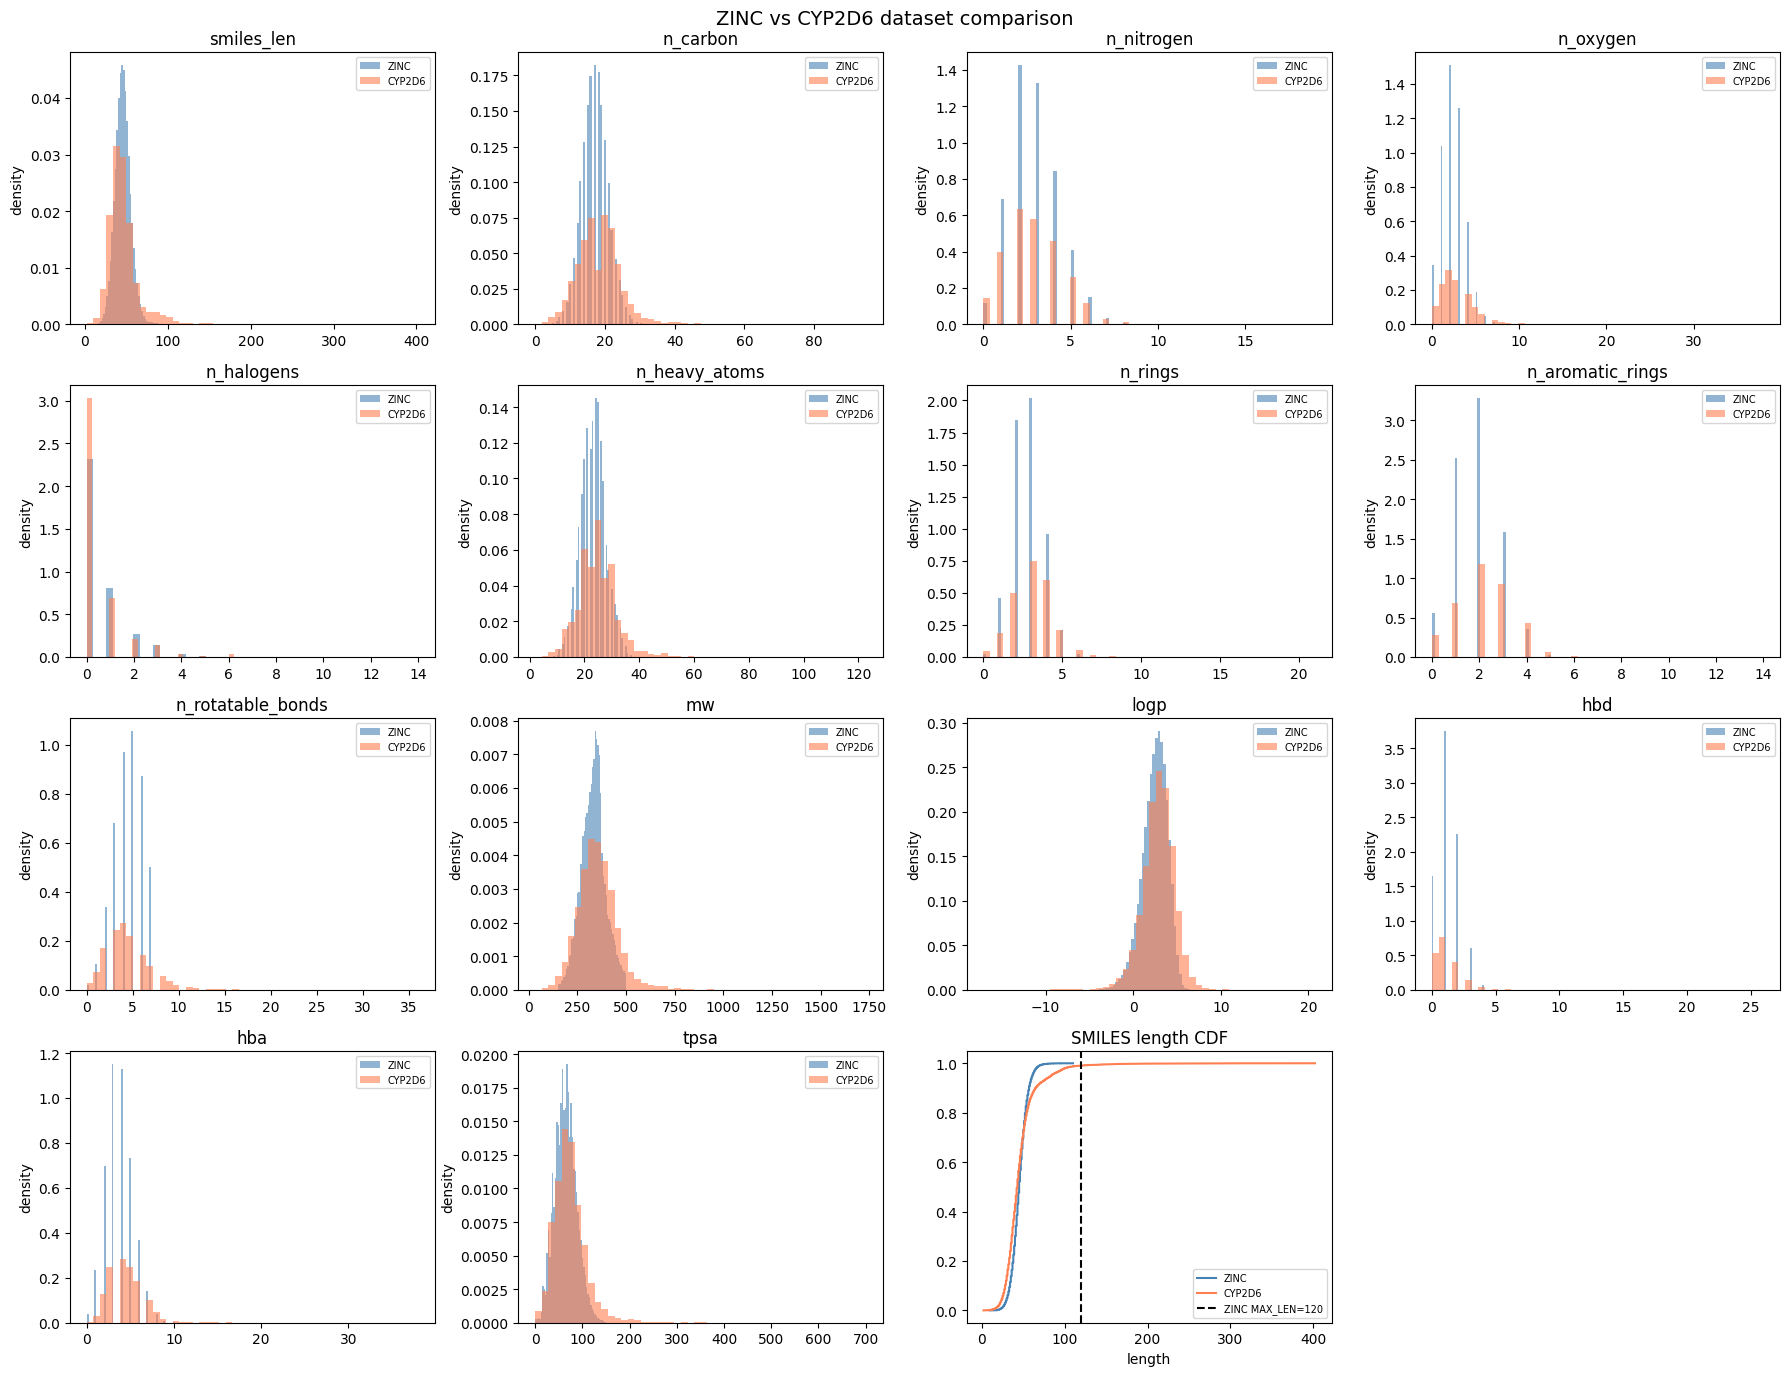

ZINC Ro5 pass rate: 98.4%
CYP2D6 Ro5 pass rate: 85.6%
ZINC SMILES <= 120 chars: 100.0%
CYP2D6 SMILES <= 120 chars: 99.1%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors, Descriptors
from collections import Counter
from tdc.single_pred import ADME

# --- Load datasets ---
data = ADME(name='CYP2D6_Veith')
split = data.get_split()
cyp_smiles = pd.concat([split['train'], split['valid'], split['test']])['Drug'].dropna().tolist()

zinc = pd.read_csv('250k_rndm_zinc_drugs_clean_3.csv')
zinc_smiles = zinc['smiles'].dropna().tolist()

# --- Feature extraction ---
def extract_features(smiles_list):
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        rows.append({
            'smiles': smi,
            'smiles_len': len(smi),
            'n_carbon': sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 6),
            'n_nitrogen': sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 7),
            'n_oxygen': sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 8),
            'n_halogens': sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() in [9, 17, 35, 53]),
            'n_heavy_atoms': mol.GetNumHeavyAtoms(),
            'n_rings': rdMolDescriptors.CalcNumRings(mol),
            'n_aromatic_rings': rdMolDescriptors.CalcNumAromaticRings(mol),
            'n_rotatable_bonds': rdMolDescriptors.CalcNumRotatableBonds(mol),
            'mw': Descriptors.MolWt(mol),
            'logp': Descriptors.MolLogP(mol),
            'hbd': rdMolDescriptors.CalcNumHBD(mol),
            'hba': rdMolDescriptors.CalcNumHBA(mol),
            'tpsa': Descriptors.TPSA(mol),
            'charset': set(smi),
        })
    return pd.DataFrame(rows)

print("Extracting ZINC features...")
df_zinc = extract_features(zinc_smiles)
df_zinc['dataset'] = 'ZINC'

print("Extracting CYP2D6 features...")
df_cyp = extract_features(cyp_smiles)
df_cyp['dataset'] = 'CYP2D6'

# --- Charset analysis ---
zinc_chars = set().union(*df_zinc['charset'])
cyp_chars = set().union(*df_cyp['charset'])
print(f"\nZINC charset ({len(zinc_chars)}): {sorted(zinc_chars)}")
print(f"CYP2D6 charset ({len(cyp_chars)}): {sorted(cyp_chars)}")
print(f"In CYP not in ZINC: {cyp_chars - zinc_chars}")
print(f"In ZINC not in CYP: {zinc_chars - cyp_chars}")

# --- Summary stats ---
features = ['smiles_len', 'n_carbon', 'n_nitrogen', 'n_oxygen', 'n_halogens',
            'n_heavy_atoms', 'n_rings', 'n_aromatic_rings', 'n_rotatable_bonds',
            'mw', 'logp', 'hbd', 'hba', 'tpsa']

df_all = pd.concat([df_zinc, df_cyp], ignore_index=True)

print("\n--- Summary statistics ---")
print(df_all.groupby('dataset')[features].describe().T)

# --- Plots ---
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    for label, color in [('ZINC', 'steelblue'), ('CYP2D6', 'coral')]:
        vals = df_all[df_all['dataset'] == label][feat].dropna()
        ax.hist(vals, bins=50, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(feat)
    ax.legend(fontsize=7)
    ax.set_ylabel('density')

# SMILES length CDF
ax = axes[len(features)]
for label, color in [('ZINC', 'steelblue'), ('CYP2D6', 'coral')]:
    vals = sorted(df_all[df_all['dataset'] == label]['smiles_len'])
    ax.plot(vals, np.linspace(0, 1, len(vals)), label=label, color=color)
ax.axvline(120, color='black', linestyle='--', label='ZINC MAX_LEN=120')
ax.set_title('SMILES length CDF')
ax.set_xlabel('length')
ax.legend(fontsize=7)

for j in range(len(features) + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('ZINC vs CYP2D6 dataset comparison', fontsize=14)
plt.tight_layout()
plt.savefig('dataset_comparison.png', dpi=150)
plt.show()

# --- Lipinski Ro5 pass rate ---
for label in ['ZINC', 'CYP2D6']:
    sub = df_all[df_all['dataset'] == label]
    ro5 = ((sub['mw'] <= 500) & (sub['logp'] <= 5) & (sub['hbd'] <= 5) & (sub['hba'] <= 10))
    print(f"{label} Ro5 pass rate: {ro5.mean():.1%}")

# --- SMILES length coverage at MAX_LEN=120 ---
for label in ['ZINC', 'CYP2D6']:
    sub = df_all[df_all['dataset'] == label]
    coverage = (sub['smiles_len'] <= 120).mean()
    print(f"{label} SMILES <= 120 chars: {coverage:.1%}")

In [2]:
lengths = pd.Series([len(s) for s in cyp_smiles])
print(f"Exceeds MAX_LEN=100: {(lengths > 100).sum()} molecules ({(lengths > 100).mean():.1%})")

Exceeds MAX_LEN=100: 260 molecules (2.0%)


In [6]:
import pandas as pd
from tdc.single_pred import ADME

zinc = pd.read_csv('250k_rndm_zinc_drugs_clean_3.csv')
df_zinc = zinc[['smiles']].dropna()

data = ADME(name='CYP2D6_Veith')
split = data.get_split()
df_cyp = pd.concat([split['train'], split['valid'], split['test']])[['Drug']].dropna()

zinc_chars = set().union(*df_zinc['smiles'].apply(set))
cyp_chars = set().union(*df_cyp['Drug'].apply(set))

print(f"ZINC vocab ({len(zinc_chars)}): {sorted(zinc_chars)}")
print(f"CYP vocab ({len(cyp_chars)}): {sorted(cyp_chars)}")
print(f"In CYP not in ZINC: {sorted(cyp_chars - zinc_chars)}")
print(f"In ZINC not in CYP: {sorted(zinc_chars - cyp_chars)}")

Found local copy...
Loading...
Done!


ZINC vocab (35): ['\n', '#', '(', ')', '+', '-', '/', '1', '2', '3', '4', '5', '6', '7', '8', '=', '@', 'B', 'C', 'F', 'H', 'I', 'N', 'O', 'P', 'S', '[', '\\', ']', 'c', 'l', 'n', 'o', 'r', 's']
CYP vocab (52): ['#', '%', '(', ')', '+', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '=', '@', 'A', 'B', 'C', 'F', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'W', 'Z', '[', '\\', ']', 'a', 'b', 'c', 'e', 'g', 'i', 'l', 'n', 'o', 'r', 's', 't', 'u']
In CYP not in ZINC: ['%', '.', '0', '9', 'A', 'K', 'L', 'M', 'R', 'W', 'Z', 'a', 'b', 'e', 'g', 'i', 't', 'u']
In ZINC not in CYP: ['\n']


## checking the frequency of each character in the CYP dataset vocabulary

In [12]:
from collections import Counter

dataset = df_cyp['Drug'].tolist()
all_chars = Counter()
for smi in dataset:
    all_chars.update(smi)

total = sum(all_chars.values())
for char, count in sorted(all_chars.items(), key=lambda x: -x[1]):
    print(f"{char}: {count} ({count/total*100:.2f}%)")

c: 140402 (23.20%)
C: 102358 (16.91%)
(: 53642 (8.86%)
): 53642 (8.86%)
1: 37184 (6.14%)
O: 36477 (6.03%)
2: 27197 (4.49%)
=: 23969 (3.96%)
N: 20592 (3.40%)
n: 17248 (2.85%)
@: 14681 (2.43%)
3: 13094 (2.16%)
[: 12922 (2.13%)
]: 12922 (2.13%)
H: 9481 (1.57%)
-: 4660 (0.77%)
4: 3858 (0.64%)
S: 3593 (0.59%)
F: 3302 (0.55%)
/: 2612 (0.43%)
l: 2491 (0.41%)
s: 1544 (0.26%)
o: 1513 (0.25%)
+: 1085 (0.18%)
\: 988 (0.16%)
#: 802 (0.13%)
.: 749 (0.12%)
5: 568 (0.09%)
B: 497 (0.08%)
r: 493 (0.08%)
P: 213 (0.04%)
a: 119 (0.02%)
6: 106 (0.02%)
I: 97 (0.02%)
A: 30 (0.00%)
7: 28 (0.00%)
8: 12 (0.00%)
i: 11 (0.00%)
u: 10 (0.00%)
b: 8 (0.00%)
K: 7 (0.00%)
%: 6 (0.00%)
e: 6 (0.00%)
t: 6 (0.00%)
0: 4 (0.00%)
g: 4 (0.00%)
M: 3 (0.00%)
Z: 3 (0.00%)
L: 3 (0.00%)
R: 3 (0.00%)
9: 2 (0.00%)
W: 1 (0.00%)
